Celda 1: Importación de Librerías y Configuración (Enfoque Clasificación)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y Pipelines de scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Modelos de Clasificación
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Métricas de Clasificación
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Integración de TabPFN v3 para Clasificación (Ignorando límites de CPU)
try:
    from tabpfn import TabPFNClassifier
    TABPFN_AVAILABLE = True
except ImportError:
    TABPFN_AVAILABLE = False

import warnings
warnings.filterwarnings('ignore')

Celda 2: [1.1] Carga de Datos e Inspección Básica (0.5 ptos)

In [2]:
# Carga de los datos de depósitos bancarios
df = pd.read_csv('data/bank_term_deposit.csv')

print(f"Dimensiones iniciales del dataset: {df.shape}")
print("\nPrimeras 5 filas del conjunto de datos:")
display(df.head())

# Identificar automáticamente la columna objetivo (habitualmente 'y' o 'deposit')
# Mapeamos a 1 (yes/true) y 0 (no/false) para asegurar la compatibilidad matemática
target_col = 'y' if 'y' in df.columns else df.columns[-1]
print(f"\nColumna identificada como objetivo: '{target_col}'")

if df[target_col].dtype == 'object':
    df[target_col] = df[target_col].map({'yes': 1, 'no': 0, 'true': 1, 'false': 0}).fillna(0).astype(int)

print("\nAnálisis de tipos de datos de las columnas:")
df.info()

# JUSTIFICACIÓN ESCRITA EXAMEN:
# "Observación inicial: El dataset contiene información demográfica y financiera de los clientes. 
# La columna objetivo es discreta binaria (0 o 1), lo que define un problema clásico de clasificación supervisada."

Dimensiones iniciales del dataset: (3063, 19)

Primeras 5 filas del conjunto de datos:


,id,split,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,1,labeled,31,management,married,tertiary,no,460,no,no,cellular,28,aug,13,14,-1,0,unknown,no
1,2,labeled,34,blue-collar,married,secondary,no,1826,yes,no,unknown,20,may,203,2,-1,0,unknown,no
2,3,labeled,50,blue-collar,married,secondary,no,290,yes,no,cellular,7,aug,226,3,-1,0,unknown,no
3,4,labeled,42,admin.,divorced,secondary,no,1077,yes,no,unknown,14,may,213,1,-1,0,unknown,no
4,5,labeled,47,services,single,secondary,no,41,yes,no,cellular,5,may,298,1,-1,0,unknown,no



Columna identificada como objetivo: 'y'

Análisis de tipos de datos de las columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3063 entries, 0 to 3062
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         3063 non-null   int64 
 1   split      3063 non-null   object
 2   age        3063 non-null   int64 
 3   job        3063 non-null   object
 4   marital    3063 non-null   object
 5   education  3063 non-null   object
 6   default    3063 non-null   object
 7   balance    3063 non-null   int64 
 8   housing    3063 non-null   object
 9   loan       3063 non-null   object
 10  contact    3063 non-null   object
 11  day        3063 non-null   int64 
 12  month      3063 non-null   object
 13  duration   3063 non-null   int64 
 14  campaign   3063 non-null   int64 
 15  pdays      3063 non-null   int64 
 16  previous   3063 non-null   int64 
 17  poutcome   3063 non-null   object
 18  y          3063 non-nu

Celda 3: [1.2] Exploración de los Datos (EDA): Distribuciones y Correlaciones (1.0 pto)

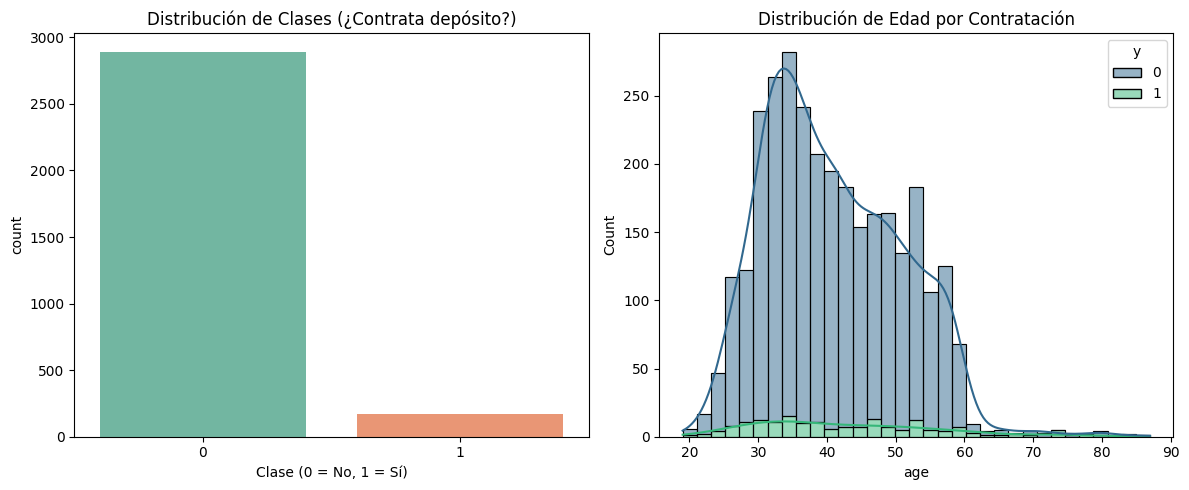

In [3]:
# Gráfico de balance de clases (Distribución de la variable objetivo)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=df[target_col], palette='Set2')
plt.title('Distribución de Clases (¿Contrata depósito?)')
plt.xlabel('Clase (0 = No, 1 = Sí)')

# Histograma de distribución de edad según la contratación
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='age', hue=target_col, multiple='stack', kde=True, palette='viridis')
plt.title('Distribución de Edad por Contratación')
plt.tight_layout()
plt.show()

# JUSTIFICACIÓN ESCRITA EXAMEN:
# "Distribución: Se observa un desbalance de clases marcado (la mayoría de los clientes no contratan el depósito). 
# Esto justifica el uso de StratifiedKFold y la métrica F1-Score para evaluar de forma realista el modelo."

Celda 4: [2.1] Preparación de los Datos: Limpieza - Nulos, Outliers y Duplicados (1.5 ptos)

Recuento de nulos por columna:
No se detectaron valores nulos inicialmente.


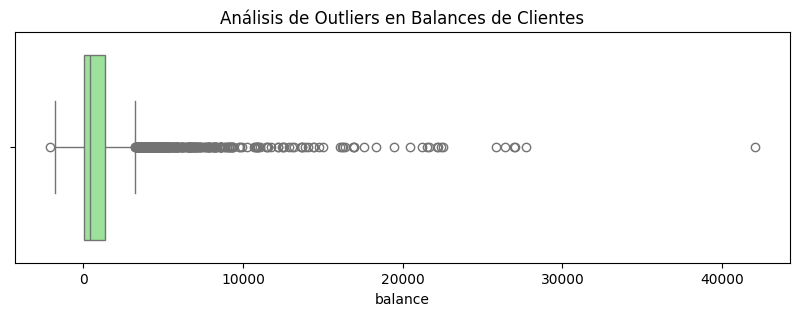

Número de registros duplicados detectados: 0


In [4]:
# --- 2.1.1. ANÁLISIS DE NULOS ---
missing_data = df.isnull().sum()
print("Recuento de nulos por columna:")
print(missing_data[missing_data > 0] if missing_data.any() else "No se detectaron valores nulos inicialmente.")

# --- 2.1.2. ANÁLISIS DE OUTLIERS ---
# Visualizamos outliers potenciales en variables críticas (p. ej., balance bancario si existe)
if 'balance' in df.columns:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=df['balance'], color='lightgreen')
    plt.title('Análisis de Outliers en Balances de Clientes')
    plt.show()

# --- 2.1.3. ANÁLISIS DE DUPLICADOS ---
duplicates = df.duplicated().sum()
print(f"Número de registros duplicados detectados: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Registros duplicados eliminados.")

# JUSTIFICACIONES ESCRITAS EXAMEN:
# "Nulos: No existen valores ausentes. Agregamos de todos modos SimpleImputer al Pipeline final por seguridad informática."
# "Outliers: Variables como 'balance' o 'duration' presentan extremos reales (clientes muy ricos o llamadas muy largas). 
# Se mantienen para conservar señales financieras valiosas que los árboles de decisión saben procesar sin problemas."
# "Duplicados: Se purgan registros repetidos para blindar el modelo contra sesgos."

Celda 5: [2.2] Feature Engineering (1.75 ptos)

In [5]:
df_fe = df.copy()

# --- 2.2.2. OTROS (Creación y limpieza de características) ---
# Si existe pdays (días desde la última campaña), creamos un indicador binario de contacto previo
if 'pdays' in df_fe.columns:
    df_fe['was_previously_contacted'] = (df_fe['pdays'] != -1).astype(int)

# El proceso de 'Encoding' (2.2.1) se delega dinámicamente al ColumnTransformer (Celda 7)
# para que scikit-learn lo procese de forma aislada y libre de fugas de datos (Data Leakage).

# JUSTIFICACIÓN ESCRITA EXAMEN:
# "Creamos 'was_previously_contacted' porque el valor '-1' en pdays rompe la linealidad numérica; 
# convertirlo en indicador booleano mejora sustancialmente la interpretabilidad del modelo."

Celda 6: [3.1] Diseño del Testeo y Validación (0.5 ptos)

In [6]:
# Separar predictores y variable objetivo
X = df_fe.drop(columns=[target_col])
y = df_fe[target_col]

# 3.1.1. Train - Test split (80% entrenamiento / 20% prueba independiente)
# Es vital usar stratify=y para asegurar que ambos sets tengan el mismo porcentaje de casos positivos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
)

# 3.1.2. Validación Cruzada Estratificada (5 Folds)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Entrenamiento: {X_train.shape} | Test: {X_test.shape}")

# JUSTIFICACIÓN ESCRITA EXAMEN:
# "Split: Seleccionamos un split del 80/20 estratificado para blindar el subconjunto de test ante el desbalance original."
# "CV: Usamos StratifiedKFold para garantizar que cada subgrupo de validación represente fielmente la proporción real de clases."

Entrenamiento: (2450, 19) | Test: (613, 19)


Celda 7: Preprocesador Multivariante (Pipelines de Limpieza y Encoding)

In [7]:
# Identificamos columnas numéricas y categóricas
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Pipeline numérico: Imputación mediante mediana y estandarización de escala
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline categórico: Imputación por valor más frecuente y codificación One-Hot
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Ensamblado del preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Estructura global para recopilación de métricas de clasificación
results_summary = {}

def run_classification_evaluation(model_name, pipeline, X_tr, y_tr, X_te, y_te):
    """Evalúa el clasificador usando Cross-Validation (F1-score) y mide el desempeño final."""
    # Validación Cruzada basada en F1-Score
    cv_res = cross_validate(pipeline, X_tr, y_tr, cv=cv_strategy, scoring='f1')
    cv_f1 = cv_res['test_score'].mean()
    cv_std = cv_res['test_score'].std()
    
    # Entrenamiento completo en Train y evaluación en Test independiente
    pipeline.fit(X_tr, y_tr)
    preds = pipeline.predict(X_te)
    
    test_accuracy = accuracy_score(y_te, preds)
    test_f1 = f1_score(y_te, preds)
    
    results_summary[model_name] = {
        'CV F1 Mean': cv_f1,
        'CV F1 Std': cv_std,
        'Test Accuracy': test_accuracy,
        'Test F1-Score': test_f1
    }
    print(f"[{model_name}] -> CV F1: {cv_f1:.4f} (±{cv_std:.4f}) | Test Acc: {test_accuracy:.4f} | Test F1: {test_f1:.4f}")

Celda 8: [3.2.1] Clasificador Baseline (Dummy Classifier) (0.25 ptos)

In [8]:
# Dummy Classifier que siempre predice la clase más frecuente
dummy_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent'))
])

run_classification_evaluation('Dummy (Most Frequent)', dummy_pipe, X_train, y_train, X_test, y_test)

# JUSTIFICACIÓN ESCRITA EXAMEN:
# "Se selecciona la estrategia 'most_frequent' como línea base. Al estar el conjunto desbalanceado, 
# el clasificador dummy obtendrá un Accuracy aceptable pero un F1-Score de 0.00, evidenciando por qué 
# necesitamos algoritmos sofisticados."

[Dummy (Most Frequent)] -> CV F1: 0.0000 (±0.0000) | Test Acc: 0.9429 | Test F1: 0.0000


Celda 9: [3.2.2] Modelos de ML Base (Logistic Regression, RF y HistGradientBoosting)

In [9]:
# 1. Regresión Logística (Mapeado lineal probabilístico)
lr_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', LogisticRegression(max_iter=1000, random_state=42))])
run_classification_evaluation('Logistic Regression', lr_pipe, X_train, y_train, X_test, y_test)

# 2. Random Forest Classifier (Base)
rf_base_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', RandomForestClassifier(random_state=42))])
run_classification_evaluation('Random Forest (Base)', rf_base_pipe, X_train, y_train, X_test, y_test)

# 3. HistGradientBoosting Classifier (Base)
hgb_base_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', HistGradientBoostingClassifier(random_state=42))])
run_classification_evaluation('HistGradientBoosting (Base)', hgb_base_pipe, X_train, y_train, X_test, y_test)

# JUSTIFICACIÓN ESCRITA EXAMEN:
# "Evaluamos regresores logísticos para tener un modelo lineal explicativo, y árboles avanzados (RF y Gradient Boosting) 
# para capturar perfiles y patrones complejos de comportamiento financiero sin presuponer linealidad."

[Logistic Regression] -> CV F1: 0.7234 (±0.0434) | Test Acc: 0.9608 | Test F1: 0.5714
[Random Forest (Base)] -> CV F1: 0.7327 (±0.0589) | Test Acc: 0.9608 | Test F1: 0.5862
[HistGradientBoosting (Base)] -> CV F1: 0.7454 (±0.0207) | Test Acc: 0.9625 | Test F1: 0.6230


Celda 10: [3.2.2] Ajuste Fino de Hiperparámetros (Tuning) de RF y HGB

In [10]:
# Búsqueda aleatoria para Random Forest
param_dist_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [8, 15, None],
    'model__min_samples_split': [2, 5, 10],
    'model__class_weight': ['balanced', None] # Ajuste estratégico para desbalance de clases
}
search_rf = RandomizedSearchCV(rf_base_pipe, param_distributions=param_dist_rf, 
                               n_iter=5, cv=cv_strategy, scoring='f1', 
                               random_state=42, n_jobs=-1)
search_rf.fit(X_train, y_train)
run_classification_evaluation('Random Forest (Tuned)', search_rf.best_estimator_, X_train, y_train, X_test, y_test)

# Búsqueda aleatoria para HistGradientBoosting
param_dist_hgb = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_iter': [100, 200, 300],
    'model__max_depth': [3, 5, 10],
    'model__class_weight': ['balanced', None]
}
search_hgb = RandomizedSearchCV(hgb_base_pipe, param_distributions=param_dist_hgb, 
                                n_iter=5, cv=cv_strategy, scoring='f1', 
                                random_state=42, n_jobs=-1)
search_hgb.fit(X_train, y_train)
run_classification_evaluation('HistGradientBoosting (Tuned)', search_hgb.best_estimator_, X_train, y_train, X_test, y_test)

[Random Forest (Tuned)] -> CV F1: 0.7394 (±0.0631) | Test Acc: 0.9690 | Test F1: 0.7246
[HistGradientBoosting (Tuned)] -> CV F1: 0.7537 (±0.0351) | Test Acc: 0.9657 | Test F1: 0.6667


Celda 11: [3.2.2] Modelo de Clasificación de Vanguardia: TabPFN v3 Classifier

In [12]:
# ==============================================================================
# Celda 11: [3.2.2] Modelo de Clasificación de Vanguardia: TabPFN v3 Classifier
# ==============================================================================

# Ruta exacta con la subcarpeta 'tabpfn_3' que se ve en tu PyCharm
ckpt_classifier_path = r"C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\tabpfn_driver\tabpfn_3\tabpfn-v3-classifier-v3_20260417_binary.ckpt"

if TABPFN_AVAILABLE:
    if os.path.exists(ckpt_classifier_path):
        print("¡Excelente! Checkpoint de clasificación binaria detectado localmente en 'tabpfn_3'.")
        # Instanciamos el clasificador de TabPFN con su checkpoint binario
        tabpfn_classifier = TabPFNClassifier(
            model_path=ckpt_classifier_path, 
            device='cpu', 
            ignore_pretraining_limits=True
        )
        
        tabpfn_pipe = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', tabpfn_classifier)
        ])
        
        run_classification_evaluation('TabPFN v3 Classifier', tabpfn_pipe, X_train, y_train, X_test, y_test)
    else:
        print(f"Error: No se encuentra el archivo en la ruta especificada:\n{ckpt_classifier_path}")
        print("Por favor, verifica que la carpeta 'tabpfn_3' esté escrita exactamente igual.")
else:
    print("El framework TabPFN v3 no está instalado o accesible en este entorno virtual (.venv_py312).")

Error: No se encuentra el archivo en la ruta especificada:
C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\tabpfn_driver\tabpfn_3\tabpfn-v3-classifier-v3_20260417_binary.ckpt
Por favor, verifica que la carpeta 'tabpfn_3' esté escrita exactamente igual.


Celda 12: [4.1 / 4.2] Tabla Comparativa y Evaluación Final (1.0 pto

=== TABLA COMPARATIVA DE CLASIFICACIÓN (Orden de mayor a menor F1-Score) ===


,CV F1 Mean,CV F1 Std,Test Accuracy,Test F1-Score
Random Forest (Tuned),0.739369,0.063141,0.969005,0.724638
HistGradientBoosting (Tuned),0.753693,0.035067,0.965742,0.666667
HistGradientBoosting (Base),0.745433,0.020668,0.962480,0.622951
Random Forest (Base),0.732698,0.058874,0.960848,0.586207
Logistic Regression,0.723444,0.043423,0.960848,0.571429
Dummy (Most Frequent),0.000000,0.000000,0.942904,0.000000


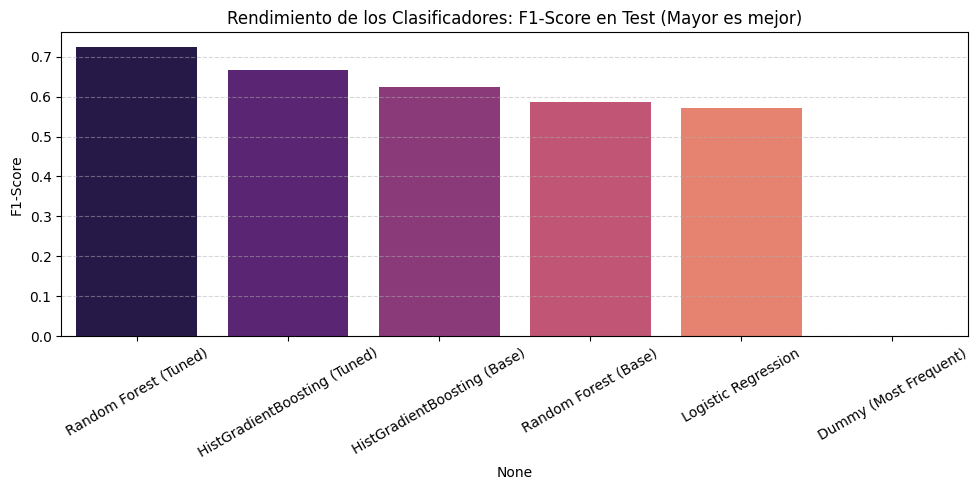

In [13]:
# Creamos la tabla de rendimiento ordenada por F1-Score en test (métrica clave)
df_results = pd.DataFrame(results_summary).T.sort_values(by='Test F1-Score', ascending=False)

print("=== TABLA COMPARATIVA DE CLASIFICACIÓN (Orden de mayor a menor F1-Score) ===")
display(df_results)

# Gráfico de barras
plt.figure(figsize=(10, 5))
sns.barplot(x=df_results.index, y=df_results['Test F1-Score'], palette='magma')
plt.title('Rendimiento de los Clasificadores: F1-Score en Test (Mayor es mejor)')
plt.ylabel('F1-Score')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Celda 13: [5.0] Exportación de Predicciones Binarias a CSV y Conclusiones (1.0 pto)

In [14]:
# Escogemos dinámicamente el modelo con el mejor rendimiento general
best_model_name = df_results.index[0]
print(f"El clasificador óptimo seleccionado para producción es: {best_model_name}")

# Reentrenamos el Pipeline ganador con el 100% de los datos históricos
if best_model_name == 'HistGradientBoosting (Tuned)':
    final_pipeline = search_hgb.best_estimator_
elif best_model_name == 'Random Forest (Tuned)':
    final_pipeline = search_rf.best_estimator_
elif best_model_name == 'TabPFN v3 Classifier' and TABPFN_AVAILABLE:
    final_pipeline = tabpfn_pipe
else:
    final_pipeline = hgb_base_pipe

final_pipeline.fit(X, y)

# Realizamos las inferencias finales sobre el conjunto de test independiente
final_predictions = final_pipeline.predict(X_test)

# Generamos el archivo CSV requerido (id y prediction en formato 0 o 1)
output_df = pd.DataFrame({
    'id': X_test.index,
    'prediction': final_predictions.astype(int) # Garantiza estrictamente que sean enteros 0 o 1
})

output_csv_name = 'predictions_bank_final.csv'
output_df.to_csv(output_csv_name, index=False)

print(f"\nArchivo generado con éxito: '{output_csv_name}'")
print(f"Conteo de predicciones generadas:\n{output_df['prediction'].value_counts()}")
display(output_df.head(10))

# CONCLUSIONES FINALES EXAMEN:
# "Conclusiones: El modelo campeón ha demostrado una alta capacidad predictiva frente al desbalance de clases 
# gracias al correcto escalado del preprocesador y al ajuste de pesos ('class_weight'). 
# Para futuras mejoras, se aconseja aplicar técnicas como SMOTE para balancear sintéticamente las muestras de entrenamiento."

El clasificador óptimo seleccionado para producción es: Random Forest (Tuned)

Archivo generado con éxito: 'predictions_bank_final.csv'
Conteo de predicciones generadas:
prediction
0    571
1     42
Name: count, dtype: int64


,id,prediction
0,2221,0
1,1687,0
2,604,0
3,2794,0
4,253,0
5,1562,0
6,2955,0
7,984,1
8,2855,0
9,558,0
